In [11]:
import csv

columns = None
passengers_on = []
passengers_off = []
with open('data-files/subway-data.csv', 'rt', encoding='utf-8') as f:
    rows = csv.reader(f)
    for idx, row in enumerate(rows):
        if idx == 0: # 첫 번째 행은 컬럼이름
            columns = row
        else:
            if row[1] == '2025-06-11':
                for idx2, v in enumerate(row[6:]):
                    v = 0 if v == '' else v
                    row[idx2 + 6] = int(v)
                if row[5] == '승차':
                    passengers_on.append(row)
                else:
                    passengers_off.append(row)

passengers_all = []
for on, off in zip(passengers_on, passengers_off):
    row = on[:6].copy()
    row[5] = '승하차'
    row = row + [ v1 + v2 for v1, v2 in zip(on[6:], off[6:])]
    passengers_all.append(row)


In [14]:
passengers_on[10][:7], passengers_off[10][:7], passengers_all[10][:7]

(['87927', '2025-06-11', '2호선', '201', '시청', '승차', 35],
 ['87928', '2025-06-11', '2호선', '201', '시청', '하차', 91],
 ['87927', '2025-06-11', '2호선', '201', '시청', '승하차', 126])

In [19]:
# 이용객수가 가장 많은 / 적은 역 조회
max_total = 0
max_idx = 0
min_total = 100000000
min_idx = 0
for idx, row in enumerate(passengers_all):
    total = sum(row[6:])
    if max_total < total:
        max_total = total
        max_idx = idx
    if min_total > total:
        min_total = total
        min_idx = idx

passengers_all[max_idx][:6], max_total, passengers_all[min_idx][:6], min_total



(['87969', '2025-06-11', '2호선', '222', '강남', '승하차'],
 174235,
 ['88019', '2025-06-11', '2호선', '247', '도림천', '승하차'],
 3181)

In [23]:
columns

['연번',
 '수송일자',
 '호선',
 '역번호',
 '역명',
 '승하차구분',
 '06시이전',
 '06-07시간대',
 '07-08시간대',
 '08-09시간대',
 '09-10시간대',
 '10-11시간대',
 '11-12시간대',
 '12-13시간대',
 '13-14시간대',
 '14-15시간대',
 '15-16시간대',
 '16-17시간대',
 '17-18시간대',
 '18-19시간대',
 '19-20시간대',
 '20-21시간대',
 '21-22시간대',
 '22-23시간대',
 '23-24시간대',
 '24시이후']

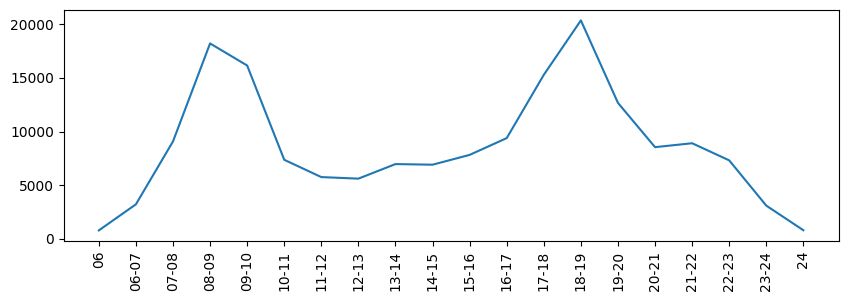

In [25]:
import matplotlib.pyplot as plt

x = [c[:-3] for c in columns[6:]]

plt.figure(figsize=(10, 3))
plt.plot(x, passengers_all[max_idx][6:])
plt.xticks(rotation=90)
plt.show()

In [29]:
# 이용객수가 가장 많은 / 적은 5개 역 조회
max_totals = []
max_idxs = []
min_totals = []
min_idxs = []
for idx, row in enumerate(passengers_all):
    total = sum(row[6:])
    if len(max_totals) < 5:
        max_totals.append(total)
        min_totals.append(total)
        max_idxs.append(idx)
        min_idxs.append(idx)
        continue # 반복문의 처음으로 이동 ( 아래 코드는 실행하지 않음 )

    if min(max_totals) < total:
        for idx2, m in enumerate(max_totals):
            if min(max_totals) == m:
                max_totals[idx2] = total
                max_idxs[idx2] = idx
                break
    if max(min_totals) > total:
        for idx2, m in enumerate(min_totals):
            if max(min_totals) == m:
                min_totals[idx2] = total
                min_idxs[idx2] = idx
                break

In [31]:
for i, id in enumerate(max_idxs):
    print(passengers_all[id][:6], max_totals[i])
print("=" * 50)
for i, id in enumerate(min_idxs):
    print(passengers_all[id][:6], min_totals[i])

['87907', '2025-06-11', '1호선', '150', '서울역', '승하차'] 147397
['88003', '2025-06-11', '2호선', '239', '홍대입구', '승하차'] 141009
['87969', '2025-06-11', '2호선', '222', '강남', '승하차'] 174235
['87989', '2025-06-11', '2호선', '232', '구로디지털단지', '승하차'] 131212
['87957', '2025-06-11', '2호선', '216', '잠실(송파구청)', '승하차'] 158727
['88015', '2025-06-11', '2호선', '245', '신답', '승하차'] 4218
['88019', '2025-06-11', '2호선', '247', '도림천', '승하차'] 3181
['88143', '2025-06-11', '4호선', '434', '남태령', '승하차'] 3192
['88079', '2025-06-11', '3호선', '336', '학여울', '승하차'] 4728
['88331', '2025-06-11', '7호선', '2711', '장암', '승하차'] 4693
